# EDA on Retail Sales Data

# Exploratory Data Analysis on Retail Sales Data

**Internship:** Oasis Infobyte (OIBSIP)

**Track:** Data Analytics

**Task:** Task 1 – EDA on Retail Sales Data

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

**Dataset:** Retail Sales Dataset

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behaviour, and business insights using Python, Pandas, Matplotlib, and Seaborn.

# Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("retail_sales_dataset.csv")


Saving retail_sales_dataset.csv to retail_sales_dataset.csv


## Initial Data Inspection

In [3]:
print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
df.head()

Shape of Dataset: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Observation

- The dataset contains customer purchase transactions.
- There are no significant missing values (verify after running).
- Data types appear suitable for analysis.

## Data Cleaning

In [4]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)
# Missing values
df.isnull().sum()

Duplicate Rows: 0
Shape after removing duplicates: (1000, 9)


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


### Observation

- The dataset contains **1000 customer transaction records** and **9 columns**.
- No duplicate records were found.
- No missing values were detected in any column.
- The dataset is clean and ready for exploratory data analysis.

## Descriptive Statistics

In [5]:
# Summary Statistics
df.describe()
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode(numeric_only=True)
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


### Observation

- The average customer age provides an overview of the customer base.
- The average quantity purchased indicates the typical number of products bought per transaction.
- Standard deviation shows how much variation exists in Age, Quantity, Price per Unit, and Total Amount.
- These statistics help understand customer purchasing behavior.

## Time Series Analysis

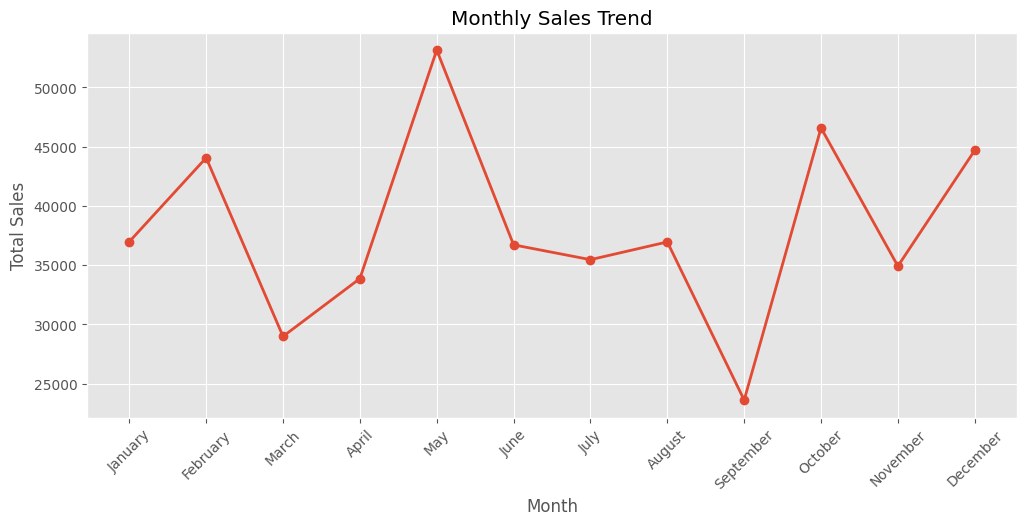

In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head()
# Create Month column
df['Month'] = df['Date'].dt.month_name()
df.head()
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)
monthly_sales = df.groupby('Month', observed=True)['Total Amount'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()


### Observation

- Monthly sales vary significantly throughout the year.
- The highest sales were recorded in **May**, indicating strong customer demand during that month.
- The lowest sales occurred in **September**, suggesting a seasonal decline.
- Sales recovered sharply in **October** and remained relatively high in **December**, indicating increased customer spending toward the end of the year.

## Quarterly Sales Trend

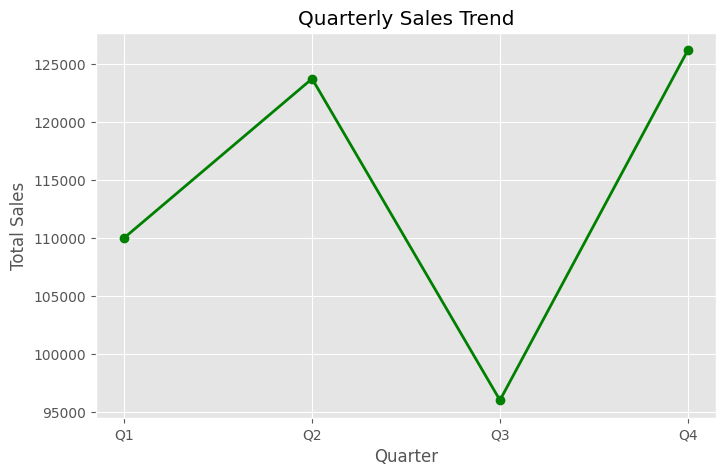

In [7]:
# Create Quarter column
df['Quarter'] = df['Date'].dt.quarter

# Quarterly Sales
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks([1,2,3,4], ['Q1','Q2','Q3','Q4'])

plt.grid(True)

plt.show()

### Observation

- Quarterly sales show noticeable fluctuations throughout the year.
- **Q4** recorded the highest sales, indicating strong customer demand during the final quarter.
- **Q3** had the lowest sales, suggesting a seasonal decline in revenue.
- Businesses can use this trend to prepare inventory, staffing, and marketing strategies for high-demand periods.

## Customer Demographics Analysis

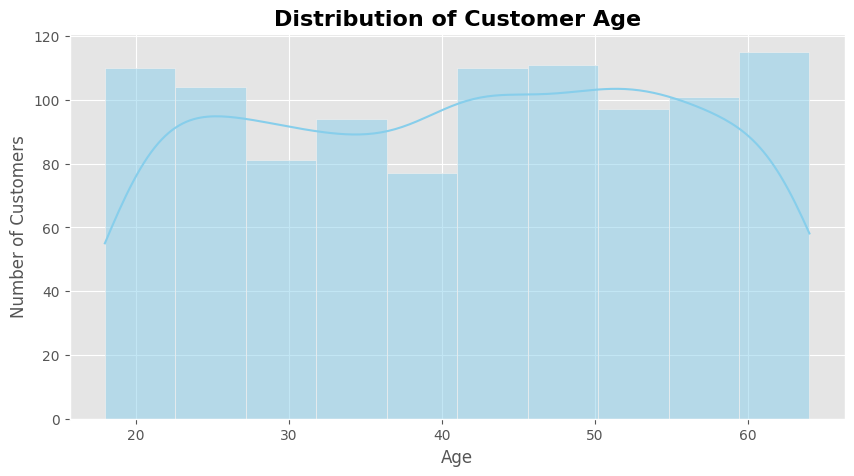

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Customer Age", fontsize=16, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- The age distribution shows how customers are spread across different age groups.
- This helps identify the primary target audience for the business.
- Marketing campaigns can be tailored to the most common customer age group.

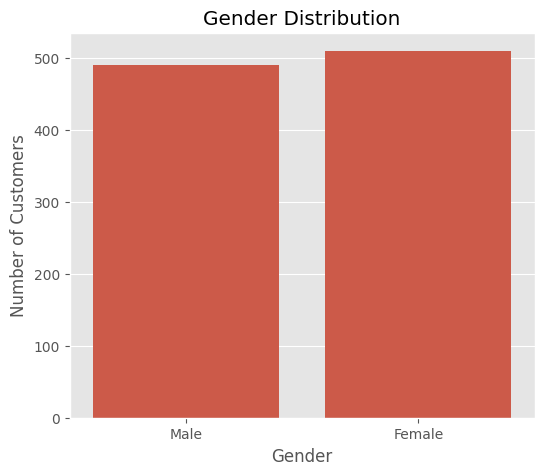

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


### Observation

- The gender distribution illustrates the proportion of male and female customers.
- Understanding gender demographics helps businesses design targeted promotional campaigns and product offerings.

**Note:** This dataset contains product categories instead of individual product names. Therefore, the analysis is based on product categories rather than specific products.

## Product Analysis

/tmp/ipykernel_1410/2506781931.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


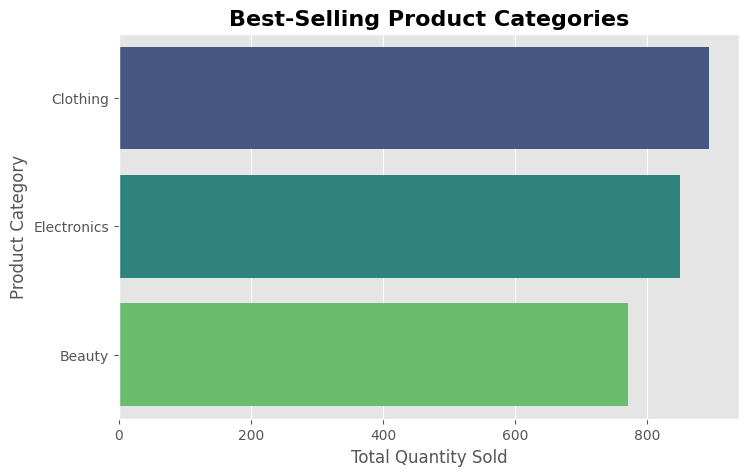

In [10]:
# Total Quantity Sold by Product Category
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)
plt.title("Best-Selling Product Categories", fontsize=16, fontweight='bold')
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")
plt.show()

### Observation

- Clothing, Electronics, and Beauty products contribute significantly to total sales quantity.
- Businesses should maintain adequate inventory for high-demand categories.

/tmp/ipykernel_1410/3953214935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


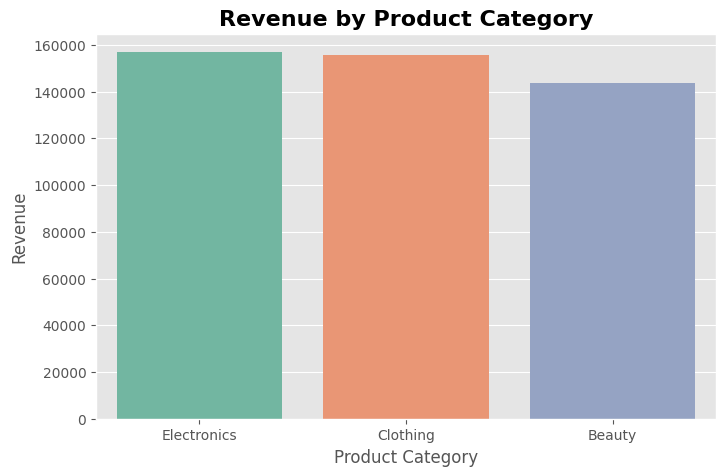

In [11]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette='Set2'
)
plt.title("Revenue by Product Category", fontsize=16, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

### Observation

- Revenue differs across product categories.
- The category with the highest revenue contributes the most to overall business performance.
- Management should focus on promoting high-performing categories while improving low-performing ones.

## Correlation Heatmap

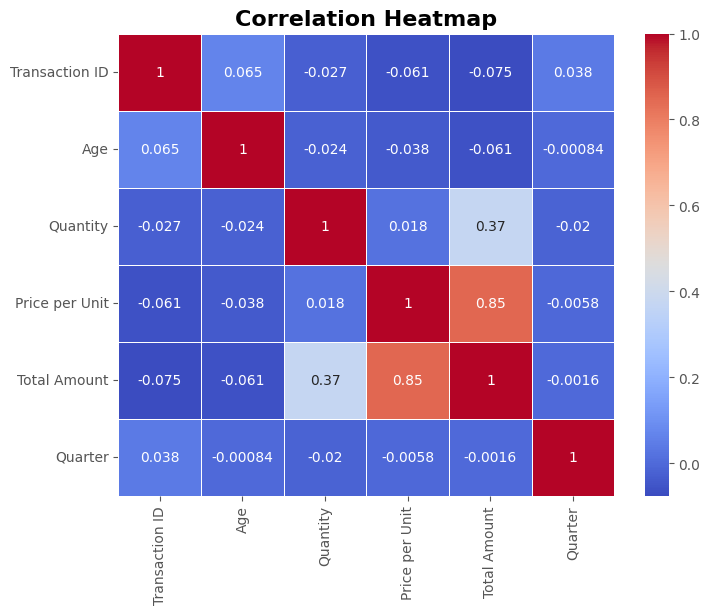

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

plt.show()

### Observation

- The heatmap shows the relationship between numerical variables.
- Total Amount has a positive relationship with Quantity and Price per Unit.
- Customer Age has a weak correlation with sales, indicating that purchasing behavior is not strongly influenced by age.

## Additional Visualization

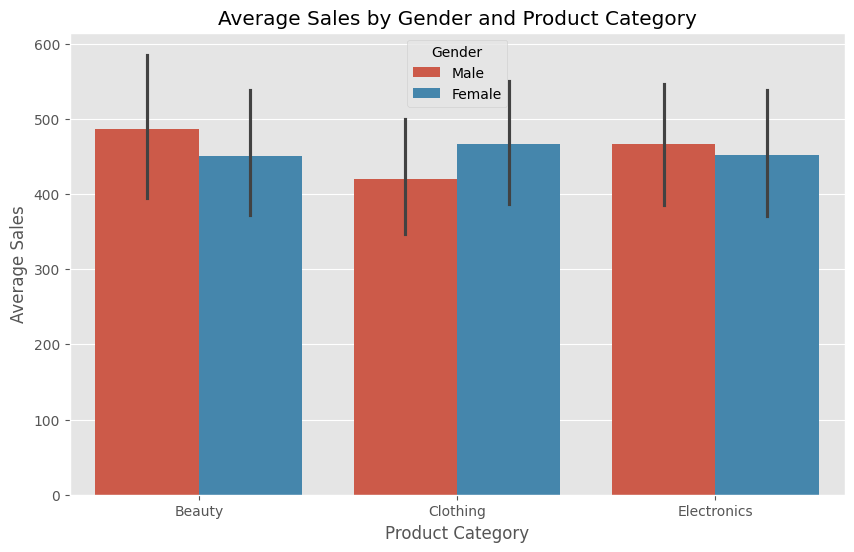

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Product Category',
    y='Total Amount',
    hue='Gender'
)

plt.title("Average Sales by Gender and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Sales")

plt.show()

### Observation

- Male customers spend more on **Beauty** and **Electronics** products on average.
- Female customers have a higher average spending on **Clothing** products.
- The differences are moderate, suggesting that purchasing preferences vary by both gender and product category.
- Businesses can use these insights to create gender-specific marketing campaigns and promotional offers.

# Business Recommendations

1. Increase inventory for Clothing products, as they have the highest sales volume.

2. Continue promoting Electronics since they generate the highest revenue.

3. Introduce promotional offers for Beauty products to improve sales performance.

4. Plan additional inventory and marketing campaigns during high-sales months and quarters.

5. Use customer demographic insights to create targeted advertisements for different age groups and genders.

# Conclusion

This exploratory data analysis examined retail sales data to understand customer behavior, sales trends, and product performance.

The analysis showed that sales vary across months and quarters, with stronger performance during the final quarter of the year. Clothing products achieved the highest sales quantity, while Electronics generated the highest revenue. Customer demographics and product preferences provide valuable insights that can support business decision-making.

These findings can help retailers improve inventory management, marketing strategies, and overall business performance.